In [1]:
#!pip install requirement
#!pip install statsmodels
#!pip install pymannkendall
import numpy as np
import matplotlib.pyplot as plt
import torch
import random

random.seed(3009)
np.random.seed(3009)
torch.manual_seed(3009)

# 0. Import et visualisation des séries temporelles

In [2]:
from src.function_kNN import load_data

elec_train , elec_miss_1 , elec_miss_2 , elec_truth ,  temp_train, temp_miss_1, temp_miss_2, temp_truth = load_data("../data/conso_france_2022")
eol_train  , eol_miss_1  , eol_miss_2  , eol_truth  ,  wind_train, wind_miss_1, wind_miss_2, wind_truth = load_data("../data/eol_hdf_2021")
photo_train, photo_miss_1, photo_miss_2, photo_truth,  sun_train , sun_miss_1 , sun_miss_2 , sun_truth  = load_data("../data/pv_occitanie_2021")

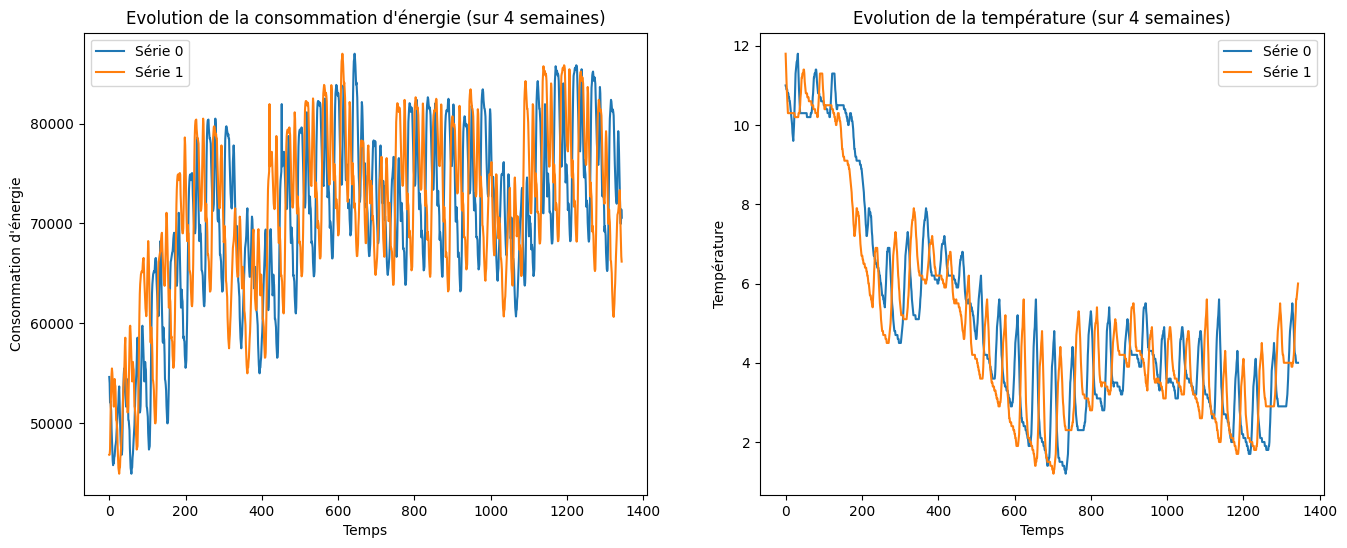

In [3]:
from src.function_kNN import plot_serie

plot_serie (elec_train, temp_train, 
            titre_1 = "Evolution de la consommation d'énergie (sur 4 semaines)", ylab_1 = "Consommation d'énergie", label_1 = "",
            titre_2 = "Evolution de la température (sur 4 semaines)", ylab_2 = "Température", label_2 ="")

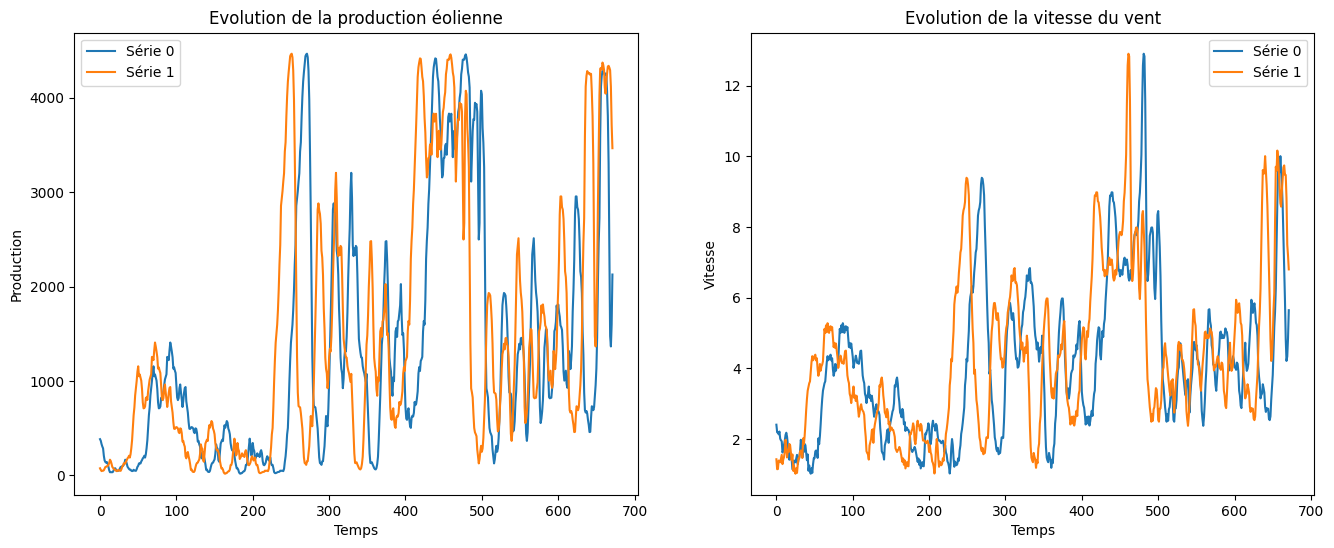

In [4]:
plot_serie (eol_train, wind_train, 
            titre_1 = "Evolution de la production éolienne", ylab_1 = "Production", label_1 = "",
            titre_2 = "Evolution de la vitesse du vent", ylab_2 = "Vitesse", label_2 ="")

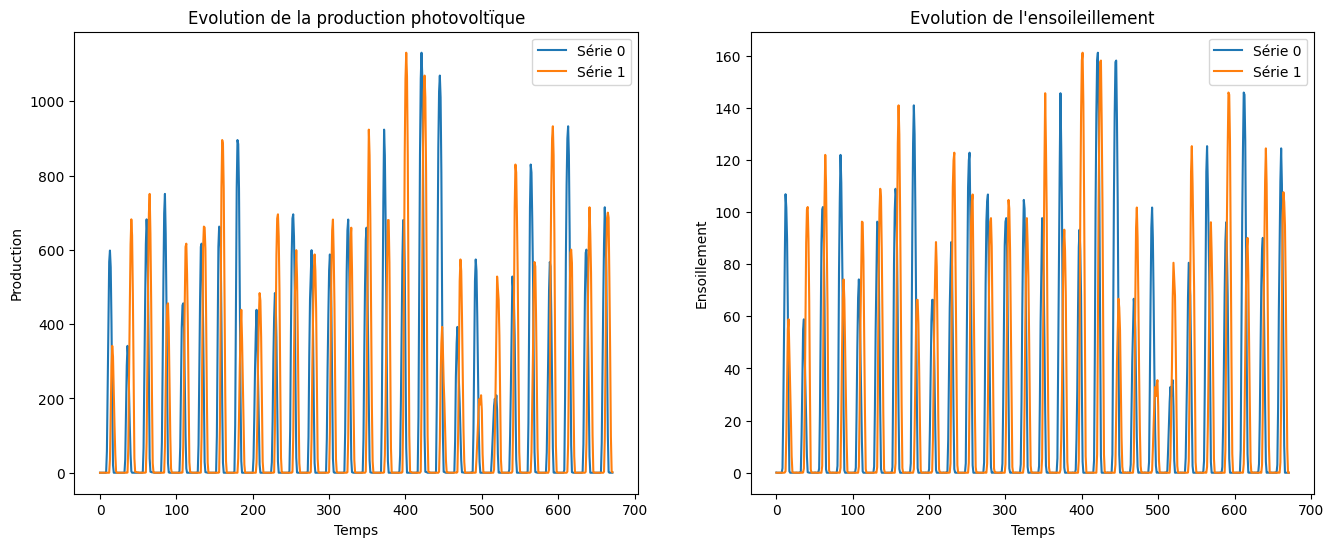

In [5]:
plot_serie (photo_train, sun_train, 
            titre_1 = "Evolution de la production photovoltïque", ylab_1 = "Production", label_1 = "",
            titre_2 = "Evolution de l'ensoileillement", ylab_2 = "Ensoillement", label_2 ="")

# I. Pré-proccessing des séries
Nous avons repris les étapes de préparation des séries et la mise en place de la k-NN régression du papier *"A methodology for applying k-nearest neighbor to time series forecasting"* (Martinez et al., 2017), en ajoutant une étape de normalisation.

**Étape 0 : Normalisation**

La normalisation par instance est appliquée sur chaque série $x$ :

$$x_{\text{norm}} = \frac{x - \bar{x}}{\sigma_x + 10^{-6}}$$

où $\bar{x} = \frac{1}{T}\sum_{t=1}^{T} x_t$ est la moyenne de la série et $\sigma_x$ son écart-type.

**Étape 1 : Gestion des outliers**

On utilise l'heuristique de Yan (2012) : $o_i$ est un outlier si

$$|o_i| \geq 4 \cdot \max\left(|\tilde{o}_{\text{avant}}|,\ |\tilde{o}_{\text{après}}|\right)$$

où $\tilde{o}_{\text{avant}} = \text{median}(o_{i-1}, o_{i-2}, o_{i-3})$ et $\tilde{o}_{\text{après}} = \text{median}(o_{i+1}, o_{i+2}, o_{i+3})$.

Si $o_i$ est détecté comme outlier, il est remplacé par :

$$o_i \leftarrow \frac{o_{i-1} + o_{i+1}}{2}$$

**Étape 2 : Transformation de Box-Cox**

On cherche à stabiliser la variance des séries présentant une saisonnalité multiplicative. En effet, la régression k-NN prédit des moyennes en fonction de l'historique — il est donc impossible de prédire des valeurs hors du champ du jeu d'entraînement, quand bien même la saisonnalité multiplicative l'exigerait.

À l'instar des modèles ARIMA, on applique la transformation de Box-Cox (Box & Jenkins) :

$$w_i = \begin{cases} \log(x_i) & \text{si } \lambda = 0 \\ \dfrac{x_i^{\lambda} - 1}{\lambda} & \text{sinon} \end{cases}$$

Le paramètre $\lambda$ est estimé automatiquement par maximum de vraisemblance pour chaque série.

**Étape 3 : Gestion de la tendance**

Une tendance dans la série peut entraîner le même problème que la saisonnalité multiplicative : une valeur réelle impossible à prédire avec une régression k-NN.

Deux options sont envisageables pour supprimer la tendance :

- **Différenciation** (comme avec les modèles ARIMA, lag = 1) : $\Delta x_t = x_t - x_{t-1}$
- **Décomposition STL** : décompose la série en deux composantes, une pour la tendance et une pour la saisonnalité et le reste.

On choisit la **différenciation**. Il faut alors identifier quelles séries sont déjà stationnaires et lesquelles doivent être différenciées, à l'aide des tests **ADF** (Augmented Dickey-Fuller) et **KPSS**.

Pour pouvoir appliquer ces tests, certaines hypothèses doivent être respectées :

-
-
-

**Étape 4 : Gestion de la saisonnalité**

Après suppression de la tendance, une saisonnalité additive résiduelle peut subsister. Deux options sont envisageables :

- **Différenciation saisonnière** (comme avec les modèles SARIMA, lag = $s$) : $\Delta_s x_t = x_t - x_{t-s}$
- **Soustraction de la moyenne saisonnière** : on calcule pour chaque instant $t$ la moyenne des observations au même instant sur les saisons passées, puis on la soustrait :

$$\tilde{x}_t = x_t - \frac{1}{K}\sum_{k=1}^{K} x_{t - k \cdot s}$$

où $s$ est la durée de la saison et $K$ le nombre de saisons observées.

In [6]:
from src.function_kNN import normalize_all, outlier, boxcox_transfo, trend_suppr, desaisonnaliser_all

elec_train_norm = normalize_all(elec_train)[0]
elec_train_outliers_out = outlier(elec_train_norm)
elec_train_bc = boxcox_transfo(elec_train_outliers_out)[0]
elec_train_detrend = trend_suppr(elec_train_bc)
elec_train_deseason_moy = desaisonnaliser_all(elec_train_detrend, "moyenne")

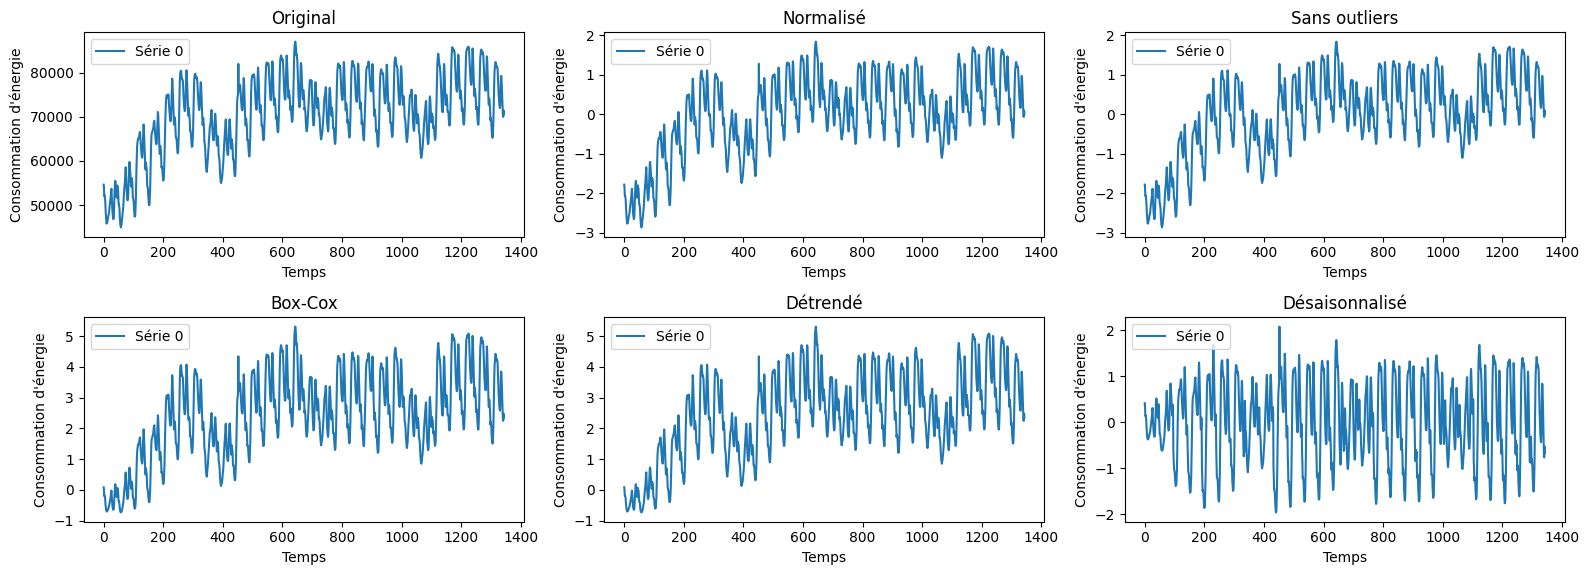

In [7]:
from src.function_kNN import plot_preprocessing

plot_preprocessing(elec_train, elec_train_norm, elec_train_outliers_out, elec_train_bc, elec_train_detrend, elec_train_deseason_moy)

**Conclusion du papier (Martinez et al., 2017)**

Toutes les étapes de transformation des séries ne sont pas nécessaires, voire même souhaitables, pour obtenir la meilleure prédiction possible (selon le score SMAPE — *Symmetric Mean Absolute Percentage Error*).

Selon les expérimentations du papier, le choix à faire à chaque étape de transformation (la normalisation n'est pas testée) est le suivant :

- **Étape 2 — Outliers** : La suppression des outliers ne semble pas particulièrement efficace pour l'amélioration des prédictions, mais l'auteur estime que cela est dû au faible nombre d'outliers supprimés dans les séries étudiées.
→ On conserve cette suppression.

- **Étape 3 — Box-Cox** : La transformation de toutes les séries n'est pas efficace ; en revanche, la transformation conditionnelle (telle qu'implémentée précédemment dans le code) améliore les prédictions, mais assez peu.
→ On peut ou non choisir d'appliquer conditionnellement la transformation Box-Cox.

- **Étape 4 — Tendance** : Les meilleures prédictions apparaissent lorsque l'on ne se préoccupe pas de la tendance.

- **Étape 5 — Saisonnalité** : Les meilleures prédictions apparaissent lorsque l'on ne se préoccupe pas de la saisonnalité. (Corroboré par nos expérimentations sur la consommation électrique)

En prenant en compte ces résultats ainsi que les travaux de Tajmouati et al. (2021) (*"Applying k-nearest neighbors to time series forecasting: two new approaches"*), on décide de conserver uniquement les étapes suivantes :

1. Normalisation
2. Gestion des outliers
3. Transformation Box-Cox

# II. Modélisation k-NN et choix des paramètres (k,p)

On reprend les algorithmes de S.Tajmouati et Al (2021)

## 1. Consomation d'énergie 
### 1.1  1 Bloc manquant

In [8]:
from src.function_kNN import find_blocks, predi_knn_general, opti_kp, plot_predictions

In [9]:
#k_opti_train_elec_1, p_opti_train_elec_1, mae_norm_opti_train_elec_1 = opti_kp(elec_train, k_min = 2, k_max = 7)
k_opti_train_elec_1, p_opti_train_elec_1, mae_norm_opti_train_elec_1 = 3, 48, 0.303

In [10]:
mape_opti_elec_1, f_opti_elec_1 , mae_opti_elec_1, mae_norm_opti_elec_1, mask_opti_elec_1, x_test_norm_opti_elec_1= predi_knn_general(elec_miss_1, k_opti_train_elec_1, p_opti_train_elec_1, elec_truth)

print(f"k={k_opti_train_elec_1}, p={p_opti_train_elec_1} | MAE_norm={np.nanmean(mae_norm_opti_elec_1):.3f}")

k=3, p=48 | MAE_norm=0.352


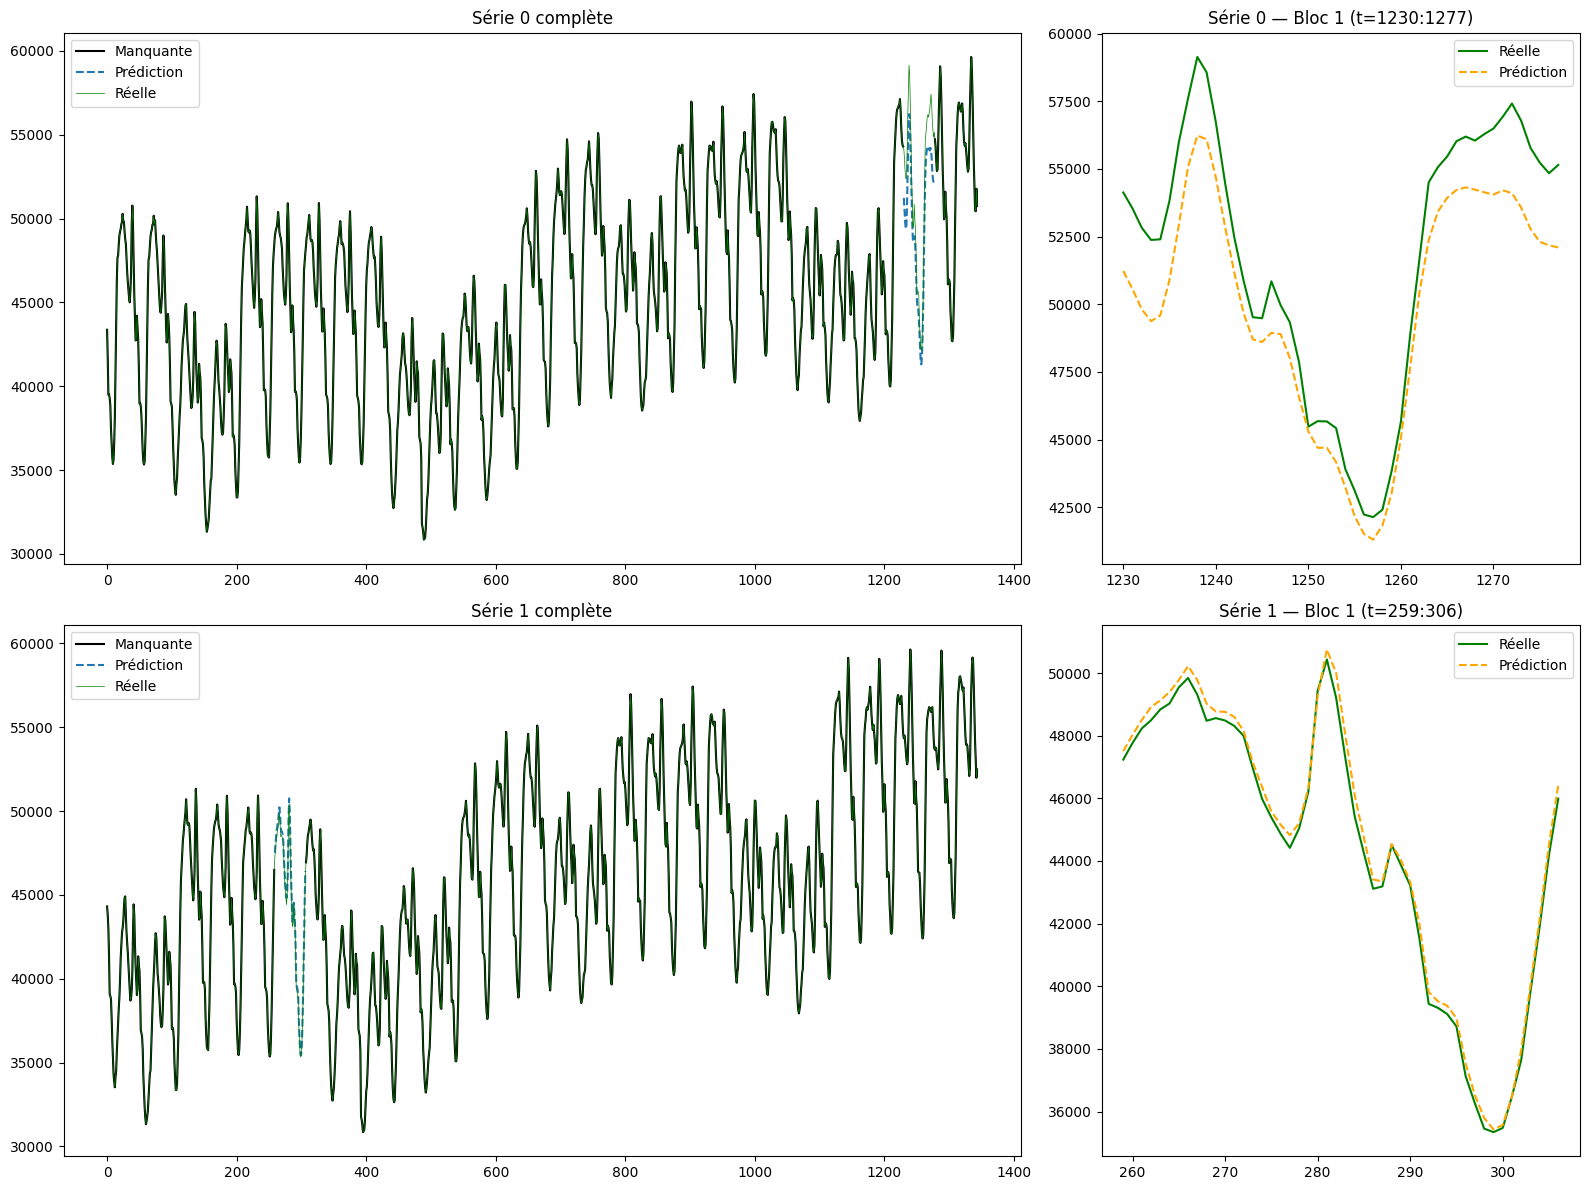

In [11]:
plot_predictions(0, 2, mask_opti_elec_1, f_opti_elec_1, elec_miss_1, elec_truth)

### 1.2  2 Blocs manquants

In [12]:
#k_opti_train_elec_2, p_opti_train_elec_2, mae_norm_opti_train_elec_2 = opti_kp(elec_train, k_min = 3, k_max = 7, nb_day_missing=2)
k_opti_train_elec_2, p_opti_train_elec_2, mae_norm_opti_train_elec_2 = 5, 24, 0.381

In [13]:
mape_opti_elec_2, f_opti_elec_2 , mae_opti_elec_2, mae_norm_opti_elec_2, mask_opti_elec_2, x_test_norm_opti_elec_2= predi_knn_general(elec_miss_2, k_opti_train_elec_2, p_opti_train_elec_2, elec_truth)

print(f"k={k_opti_train_elec_2}, p={p_opti_train_elec_2} | MAE_norm={np.nanmean(mae_norm_opti_elec_2):.3f}")

k=5, p=24 | MAE_norm=0.416


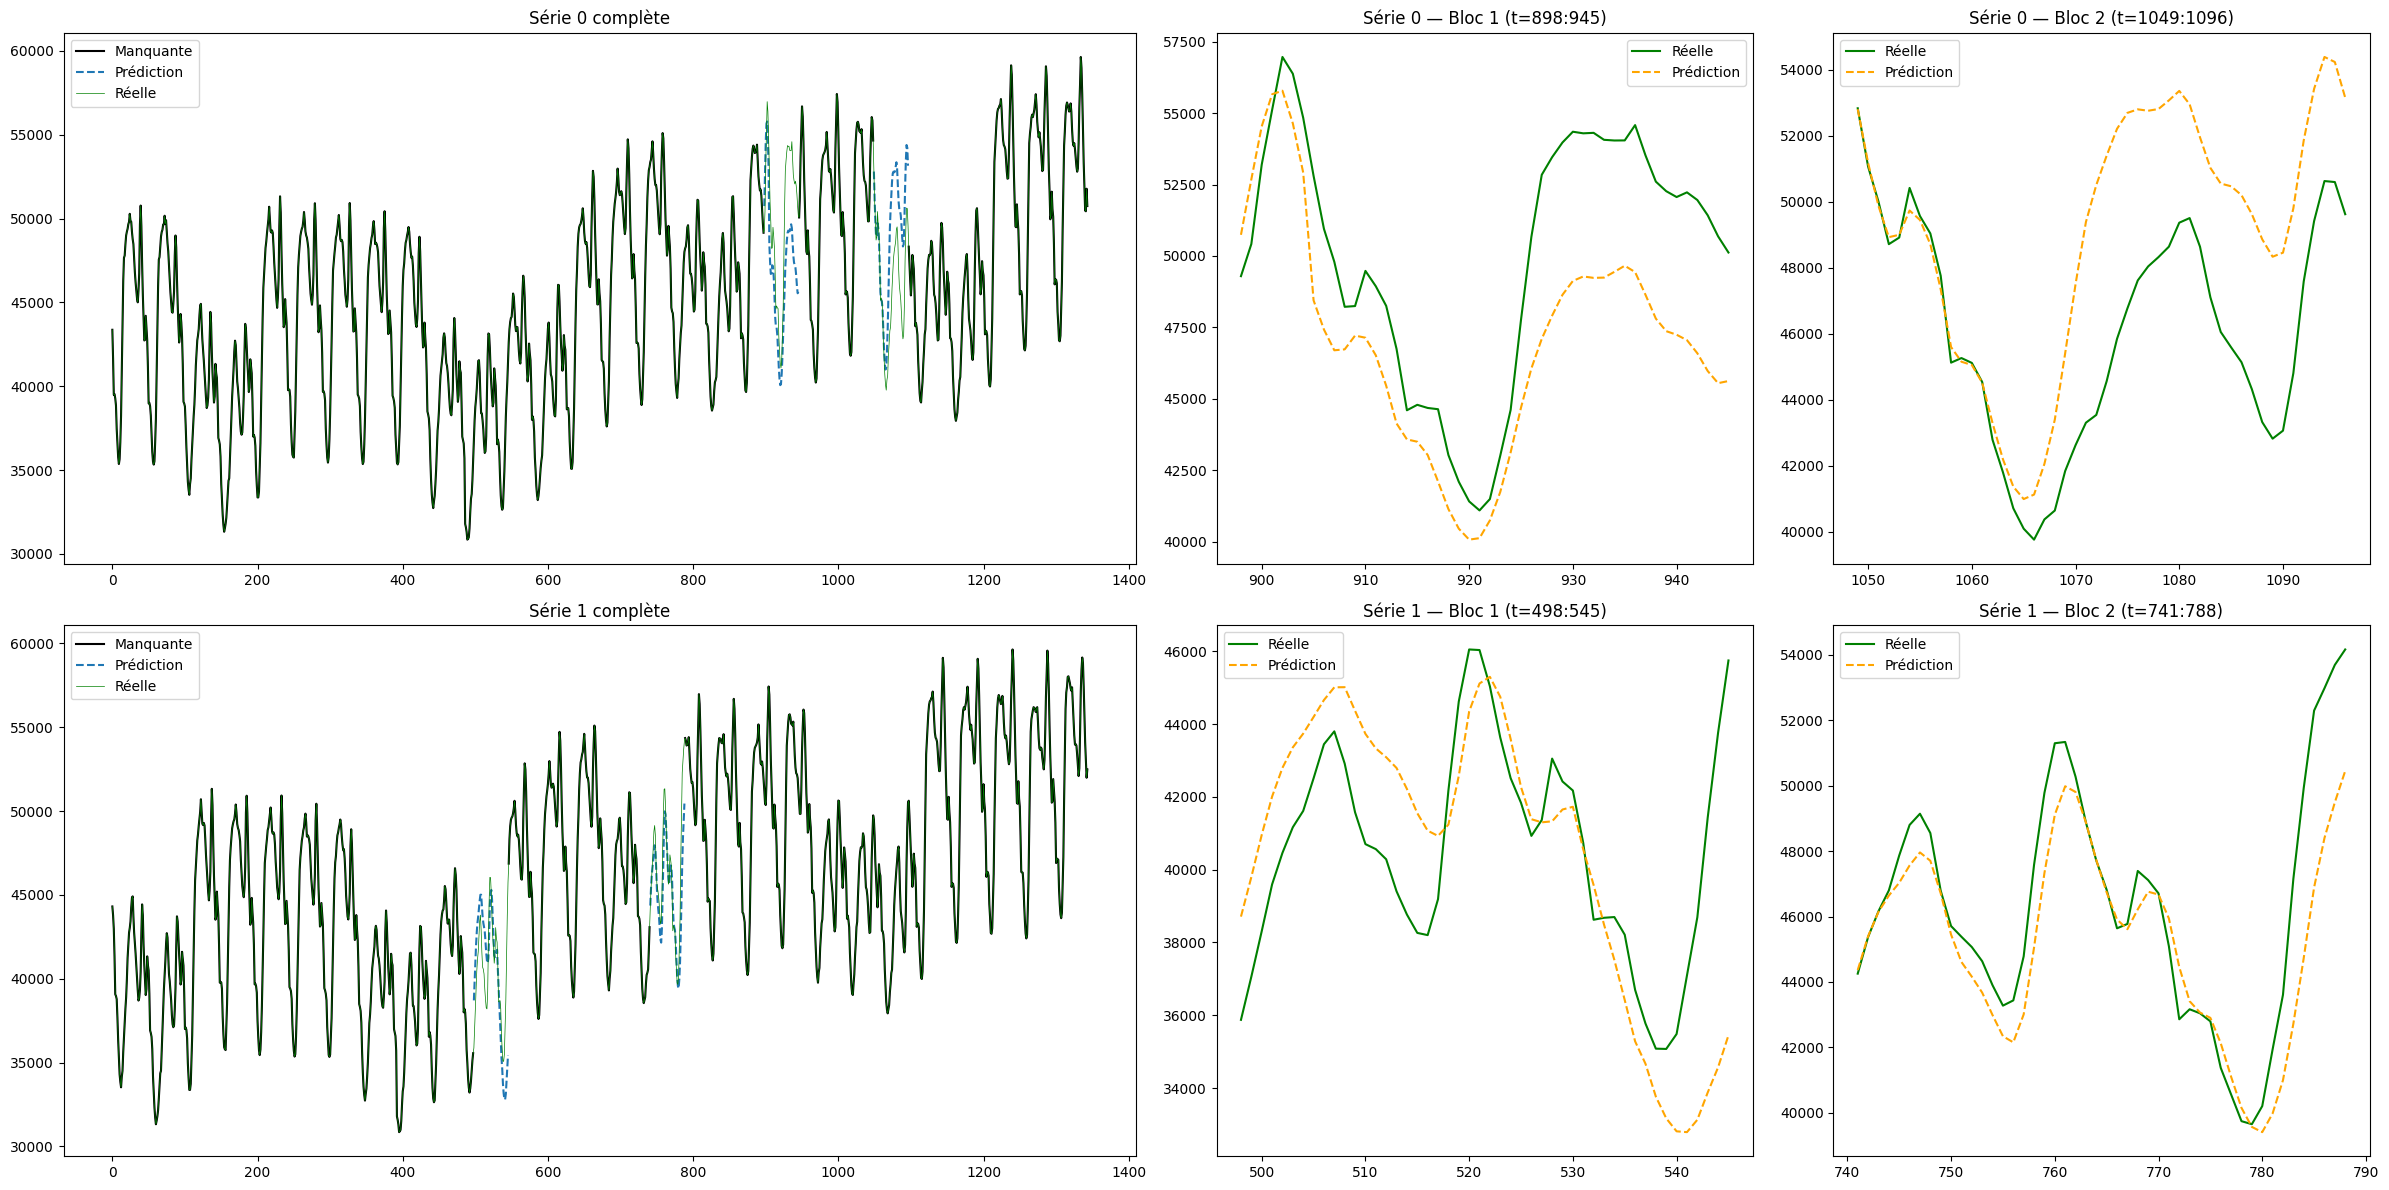

In [14]:
plot_predictions(0, 2, mask_opti_elec_2, f_opti_elec_2, elec_miss_2, elec_truth)

| Dataset | Setting | TabPFN | Ridge on Covar | k-NN |
|:--------|:--------|-------:|---------------:|------:|
| conso france 2022 | *Blocks 1* | 0.143 | 0.669 | **0.352** (k=3,p=48) |
| | *Blocks 2* | 0.170 | 0.674 | **0.416** (k=5,p=24) |

## 2. Eolienne
### 2.1  1 Bloc manquant

In [15]:
#k_opti_train_eol_1, p_opti_train_eol_1, mae_norm_opti_train_eol_1 = opti_kp(eol_train, k_min = 5, k_max = 10)
k_opti_train_eol_1, p_opti_train_eol_1, mae_norm_opti_train_eol_1 = 7,  8,  0.622

In [16]:
mape_opti_eol_1, f_opti_eol_1 , mae_opti_eol_1, mae_norm_opti_eol_1, mask_opti_eol_1, x_test_norm_opti_eol_1= predi_knn_general(eol_miss_1, k_opti_train_eol_1, p_opti_train_eol_1, eol_truth)

print(f"k={k_opti_train_eol_1}, p={p_opti_train_eol_1} | MAE_norm={np.nanmean(mae_norm_opti_eol_1):.3f}")

k=7, p=8 | MAE_norm=0.695


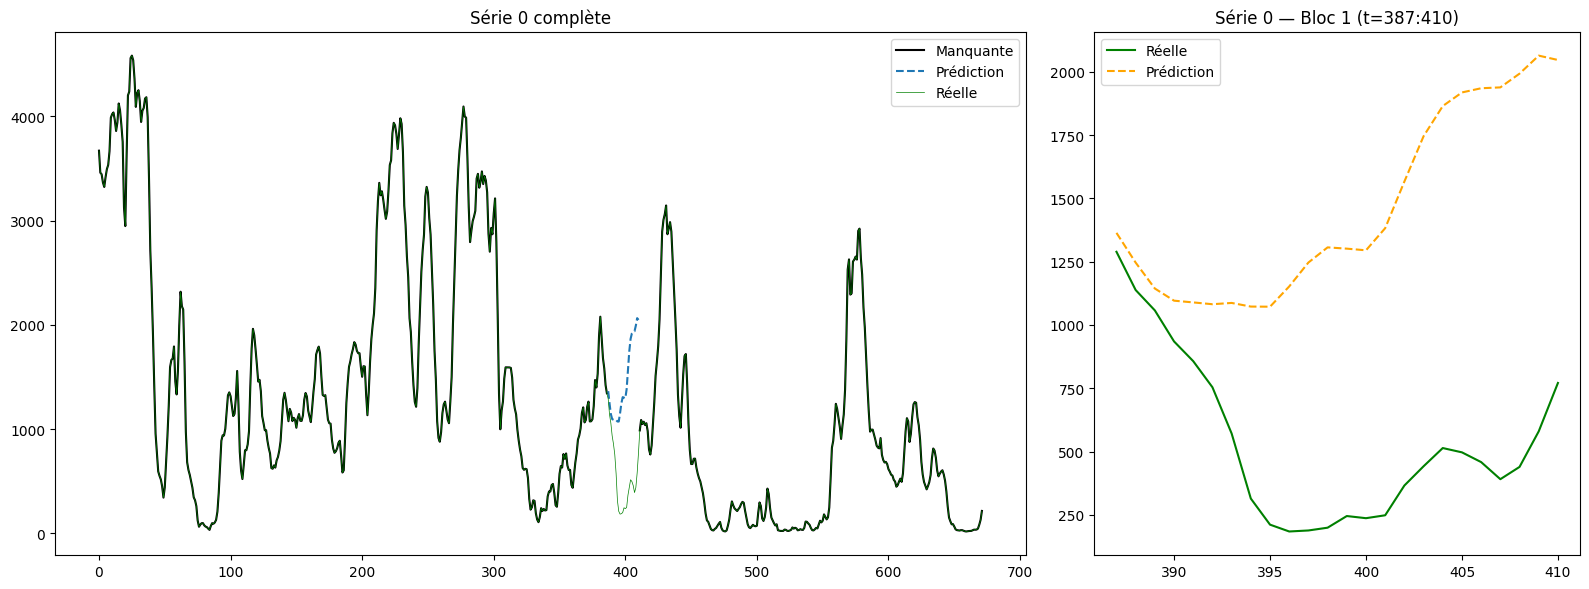

In [17]:
plot_predictions(0, 1, mask_opti_eol_1, f_opti_eol_1, eol_miss_1, eol_truth)

### 2.2  2 Blocs manquants

In [18]:
#k_opti_train_eol_2, p_opti_train_eol_2, mae_norm_opti_train_eol_2 = opti_kp(eol_train, k_min = 4, k_max = 8)
k_opti_train_eol_2, p_opti_train_eol_2, mae_norm_opti_train_eol_2 =  7,  4,  0.639

In [19]:
mape_opti_eol_2, f_opti_eol_2 , mae_opti_eol_2, mae_norm_opti_eol_2, mask_opti_eol_2, x_test_norm_opti_eol_2= predi_knn_general(eol_miss_2, k_opti_train_eol_2, p_opti_train_eol_2, eol_truth)

print(f"k={k_opti_train_eol_2}, p={p_opti_train_eol_2} | MAE_norm={np.nanmean(mae_norm_opti_eol_2):.3f}")

k=7, p=4 | MAE_norm=0.691


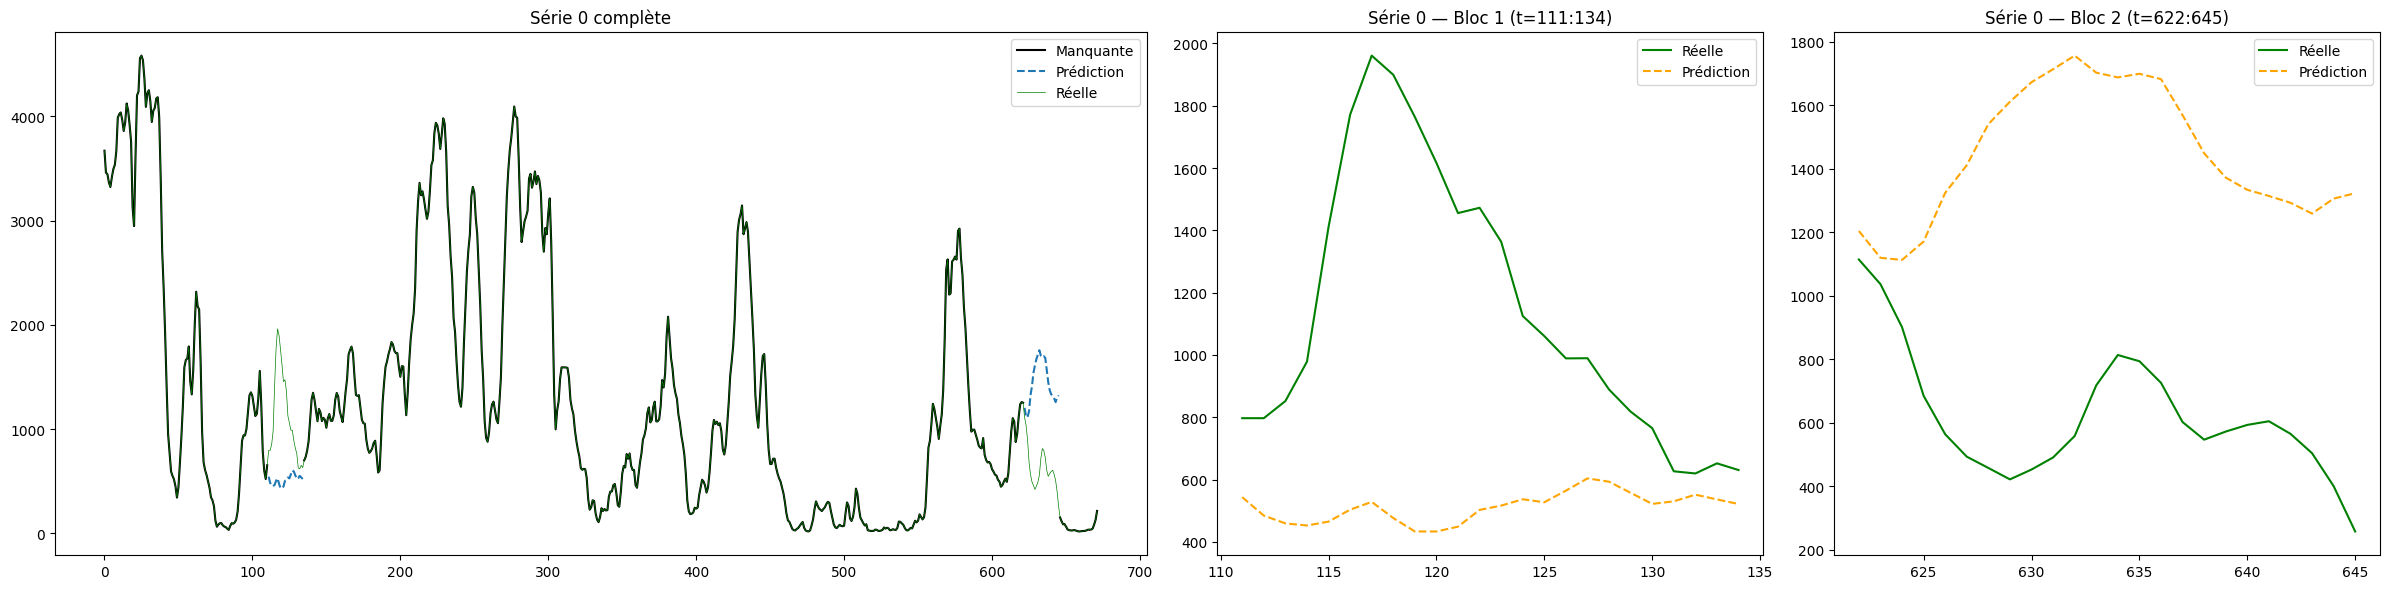

In [20]:
plot_predictions(0, 1, mask_opti_eol_2, f_opti_eol_2, eol_miss_2, eol_truth)

| Dataset | Setting | TabPFN | Ridge on Covar | k-NN |
|:--------|:--------|-------:|---------------:|------:|
| eol hdf 2021 | *Blocks 1* | 0.275 | 0.321 | 0.695 (k=7,p=8) |
| | *Blocks 2* | 0.248 | 0.335 | 0.691 (k=7,p=4) |

## 3. Photovoltaïque
### 3.1  1 Bloc manquant

In [21]:
#k_opti_train_photo_1, p_opti_train_photo_1, mae_norm_opti_photo_1 = opti_kp(photo_train, k_min=3, k_max=7, I=1, n=48, nb_day_missing=1)
k_opti_train_photo_1, p_opti_train_photo_1, mae_norm_opti_photo_1 =  7, 24, 0.198

In [22]:
mape_opti_photo_1, f_opti_photo_1 , mae_opti_photo_1, mae_norm_opti_photo_1, mask_opti_photo_1, x_test_norm_opti_photo_1= predi_knn_general(photo_miss_1, k_opti_train_photo_1, p_opti_train_photo_1, photo_truth)

print(f"k={k_opti_train_photo_1}, p={p_opti_train_photo_1} | MAE_norm={np.nanmean(mae_norm_opti_photo_1):.3f}")

k=7, p=24 | MAE_norm=0.211


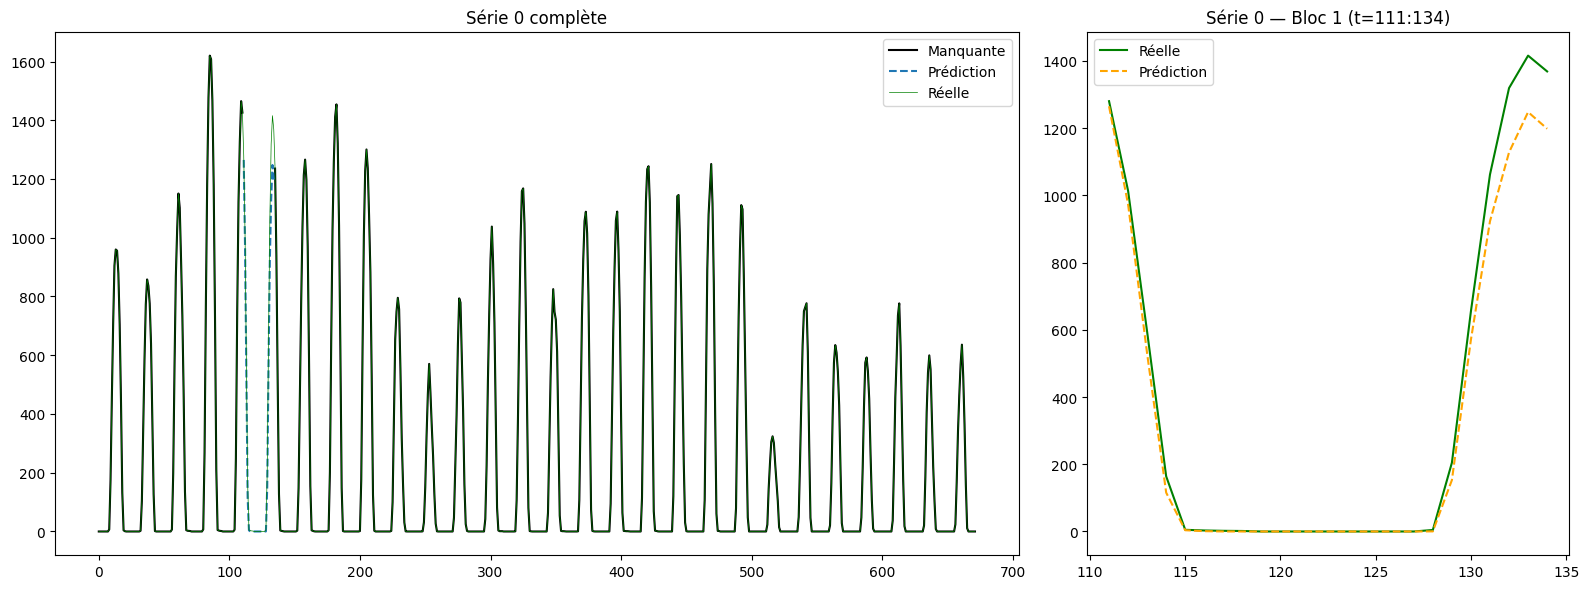

In [23]:
plot_predictions(0, 1, mask_opti_photo_1, f_opti_photo_1, photo_miss_1, photo_truth)

### 3.2  2 Blocs manquants

In [24]:
#k_opti_train_photo_2, p_opti_train_photo_2, mae_norm_opti_photo_2 = opti_kp(photo_train, k_min=3, k_max=7, I=1, n=48, nb_day_missing=2)
k_opti_train_photo_2, p_opti_train_photo_2, mae_norm_opti_photo_2 = 4, 12 ,0.000 # pas la bonne mae

In [25]:
mape_opti_photo_2, f_opti_photo_2 , mae_opti_photo_2, mae_norm_opti_photo_2, mask_opti_photo_2, x_test_norm_opti_photo_2= predi_knn_general(photo_miss_2, k_opti_train_photo_2, p_opti_train_photo_2, photo_truth)

print(f"k={k_opti_train_photo_2}, p={p_opti_train_photo_2} | MAE_norm={np.nanmean(mae_norm_opti_photo_2):.3f}")

k=4, p=12 | MAE_norm=0.270


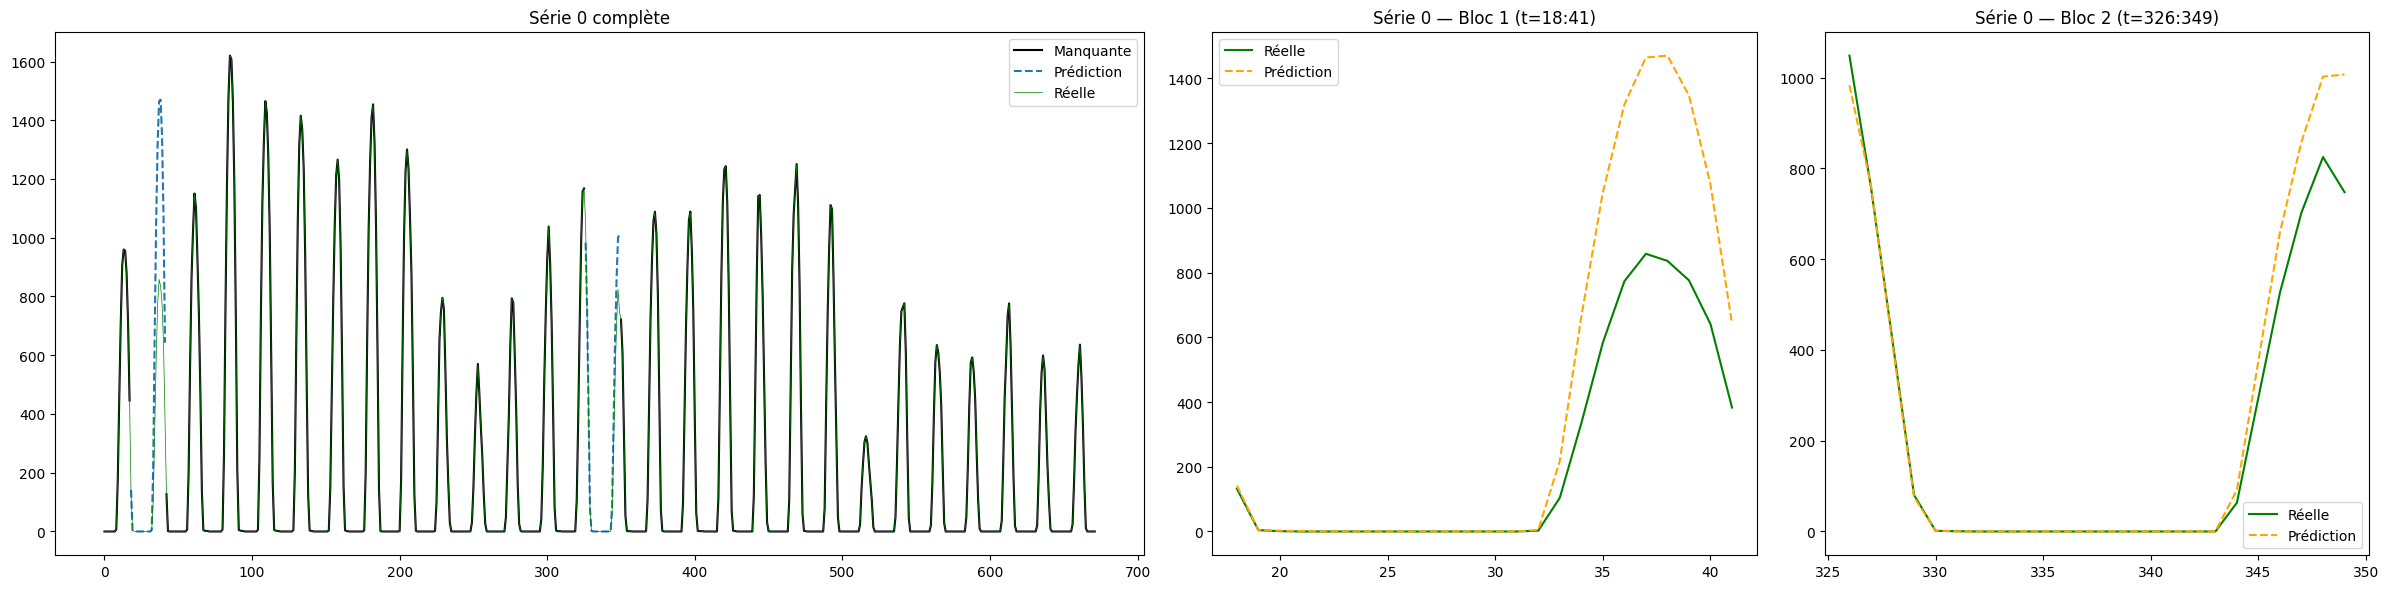

In [26]:
plot_predictions(0, 1, mask_opti_photo_2, f_opti_photo_2, photo_miss_2, photo_truth)

| Dataset | Setting | TabPFN | Ridge on Covar | k-NN |
|:--------|:--------|-------:|---------------:|------:|
| pv occitanie 2021 | *Blocks 1* | 0.052 | 0.104 | 0.211 (k=7,p=24) |
| | *Blocks 2* | 0.049 | 0.106 | 0.270 (k=4,p=12) |

# Tableau Récapitulatif

La régression k-NN est très utile pour imputer les valeurs manquantes sur le jeu de données concernant la consommation électrique, car les séries forment des patterns récurrents, ce qui permet de ne pas trop se tromper lorsqu'on l'on moyennise les valeurs obtennus sur des jours différents mais semblable.  
En revanche, dans les deux autres cas, la covariable est trop utile pour prédire les valeurs de la variable d'intêret. Il est donc difficile de s'en passer pour faire de bonnes estimations. Le modèle k-NN univarié a donc plus de mal que les régression qui emploie la covariable a avoir une erreur de prédiction faible. 

| Dataset | Setting | TabPFN | Ridge on Covar | k-NN |
|:--------|:--------|-------:|---------------:|------:|
| pv occitanie 2021 | *Blocks 1* | 0.052 | 0.104 | 0.211 (k=7,p=24) |
| | *Blocks 2* | 0.049 | 0.106 | 0.270 (k=4,p=12) |
| eol hdf 2021 | *Blocks 1* | 0.275 | 0.321 | 0.695 (k=7,p=8) |
| | *Blocks 2* | 0.248 | 0.335 | 0.691 (k=7,p=4) |
| conso france 2022 | *Blocks 1* | 0.143 | 0.669 | **0.352** (k=3,p=48) |
| | *Blocks 2* | 0.170 | 0.674 | **0.416** (k=5,p=24) |